<a href="https://colab.research.google.com/github/fasyabrhns/Tensorflow-in-Actions/blob/main/4_2_Convolution_networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing necessary libraries

In [11]:
import random
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models
import tensorflow.keras.backend as K
import matplotlib.pyplot as plt
%matplotlib inline

def fix_random_seed(seed):
    """ Setting the random seed of various libraries """
    try:
        np.random.seed(seed)
    except NameError:
        print("Warning: Numpy is not imported. Setting the seed for Numpy failed.")
    try:
        tf.random.set_seed(seed)
    except NameError:
        print("Warning: TensorFlow is not imported. Setting the seed for TensorFlow failed.")
    try:
        random.seed(seed)
    except NameError:
        print("Warning: random module is not imported. Setting the seed for random failed.")

# Fixing the random seed
fix_random_seed(4321)
print("TensorFlow version: {}".format(tf.__version__))

TensorFlow version: 2.19.0


## Loading and Exploring the data

Here we will load the dataset using the `tensorflow-datasets` library. Next, we will print the very first item in the dataset and see what we have. You will see that image data varies between [0,255]. Finally, we will plot some of the images to understand the classes and images we have to work with. We will not explore this too much as we have already worked with this dataset briefly in Chapter 2.

In [12]:
# Section 4.2

import tensorflow_datasets as tfds
# Loading the CIFAR10 dataset
data = tfds.load('cifar10')

In [13]:
print(data)

{'train': <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>, 'test': <_PrefetchDataset element_spec={'id': TensorSpec(shape=(), dtype=tf.string, name=None), 'image': TensorSpec(shape=(32, 32, 3), dtype=tf.uint8, name=None), 'label': TensorSpec(shape=(), dtype=tf.int64, name=None)}>}


In [14]:
# Section 4.2

# Let's see the first element in the training set
for i in data["train"].take(1):
    print(i)

{'id': <tf.Tensor: shape=(), dtype=string, numpy=b'train_16399'>, 'image': <tf.Tensor: shape=(32, 32, 3), dtype=uint8, numpy=
array([[[143,  96,  70],
        [141,  96,  72],
        [135,  93,  72],
        ...,
        [ 96,  37,  19],
        [105,  42,  18],
        [104,  38,  20]],

       [[128,  98,  92],
        [146, 118, 112],
        [170, 145, 138],
        ...,
        [108,  45,  26],
        [112,  44,  24],
        [112,  41,  22]],

       [[ 93,  69,  75],
        [118,  96, 101],
        [179, 160, 162],
        ...,
        [128,  68,  47],
        [125,  61,  42],
        [122,  59,  39]],

       ...,

       [[187, 150, 123],
        [184, 148, 123],
        [179, 142, 121],
        ...,
        [198, 163, 132],
        [201, 166, 135],
        [207, 174, 143]],

       [[187, 150, 117],
        [181, 143, 115],
        [175, 136, 113],
        ...,
        [201, 164, 132],
        [205, 168, 135],
        [207, 171, 139]],

       [[195, 161, 126],
        [18

## Plotting the data

Let's plot some data along with the image categories for those images.

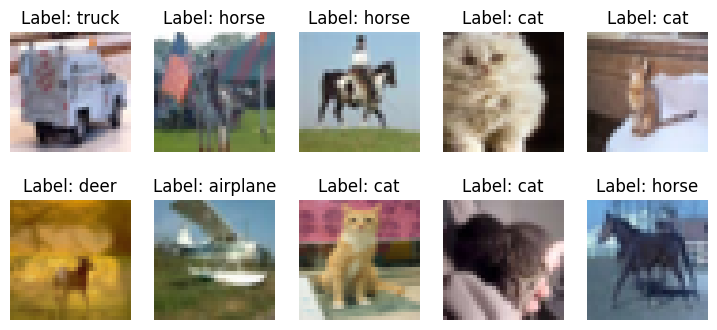

In [15]:
# Section 4.2

import matplotlib.pyplot as plt
%matplotlib inline

# Take 10 samples randomly to plot
sample_images, sample_labels = [],[]
for d in data["train"].shuffle(100, seed=4321).take(10):
    sample_images.append(d["image"].numpy())
    sample_labels.append(d["label"].numpy())

# Creating a label map mapping the integer label to the string
label_map = dict(zip(
    list(range(10)),
    ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]))

# Plotting the images
f, axes = plt.subplots(2, 5, figsize=(9,4))
for i, (img, lbl) in enumerate(zip(sample_images, sample_labels)):
    r, c = i//5, i%5
    axes[r,c].imshow(img,cmap='gray')
    axes[r,c].axis('off')
    axes[r,c].set_title("Label: {}".format(label_map[lbl]))

## Defining the model

Let's define a CNN model. But wait, we are getting an error trying to run this model. This is because, one needs to be careful of the output sizes of the model's each layer. In this case, the model we created has led to an invalid height and width dimensions **causing an error**.

In [16]:
# Section 4.2
# Code listing 4.2

from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

K.clear_session()

# Defining the CNN model
cnn = models.Sequential(
    [layers.Conv2D(filters=16,kernel_size=(9,9), strides=(2,2), activation='relu', input_shape=(32,32,3)), # 32->12
     layers.Conv2D(32, (7,7), activation='relu'), # 12 -> 6
     layers.Conv2D(64, (7,7), activation='relu'), # 6 -> -1
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')]
)

## Defining the model the correct way

Good thing we got that error out of the way. Now let's fix the model above so we don't have any errors.

In [17]:
# Section 4.2
# Code listing 4.3

from tensorflow.keras import layers, models
import tensorflow.keras.backend as K

K.clear_session()

# Defining the CNN model without any errores
cnn = models.Sequential(
    [layers.Conv2D(filters=16,kernel_size=(3,3), strides=(2,2), activation='relu', padding='same', input_shape=(32,32,3)), # 32->16
     layers.MaxPool2D(pool_size=(2,2), strides=(2,2), padding='same'), # 16->8
     layers.Conv2D(32, (3,3), activation='relu', padding='same'), # 8 -> 8
     layers.MaxPool2D(pool_size=(2,2), strides=(2,2), padding='same'), # 8->4
     layers.Flatten(),
     layers.Dense(64, activation='relu'),
     layers.Dense(32, activation='relu'),
     layers.Dense(10, activation='softmax')]
)

# Compiling the model
cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['acc'])

## Training the model

Finally, you can train the model. But to do that we will need to slightly change the dataset object we have. We will convert the images to `float32` (which are originally `uint8`) and convert labels to one-hot encoded vectors. To do this we will use the `tf.data.DataSet.map()` function as we have done earlier.

Now let's train the model. We can see that training accuracy of the model is growing steadily. That's a great result!

In [18]:
# Section 4.2

import tensorflow as tf

def format_data(x, depth):
    """ Create a tuple where 1st element is a batch of images
    and the second is a batch of onehot encoded vectors"""
    return (tf.cast(x["image"], 'float32'), tf.one_hot(x["label"], depth=depth))

# Map the dataset using the function
tr_data = data["train"].map(lambda x: format_data(x, depth=10)).batch(32)

In [19]:
for d in tr_data.take(1):
    print(d)

(<tf.Tensor: shape=(32, 32, 32, 3), dtype=float32, numpy=
array([[[[143.,  96.,  70.],
         [141.,  96.,  72.],
         [135.,  93.,  72.],
         ...,
         [ 96.,  37.,  19.],
         [105.,  42.,  18.],
         [104.,  38.,  20.]],

        [[128.,  98.,  92.],
         [146., 118., 112.],
         [170., 145., 138.],
         ...,
         [108.,  45.,  26.],
         [112.,  44.,  24.],
         [112.,  41.,  22.]],

        [[ 93.,  69.,  75.],
         [118.,  96., 101.],
         [179., 160., 162.],
         ...,
         [128.,  68.,  47.],
         [125.,  61.,  42.],
         [122.,  59.,  39.]],

        ...,

        [[187., 150., 123.],
         [184., 148., 123.],
         [179., 142., 121.],
         ...,
         [198., 163., 132.],
         [201., 166., 135.],
         [207., 174., 143.]],

        [[187., 150., 117.],
         [181., 143., 115.],
         [175., 136., 113.],
         ...,
         [201., 164., 132.],
         [205., 168., 135.],
         

In [20]:
# Section 4.2
# Fit the data
history = cnn.fit(tr_data,epochs=25)

Epoch 1/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - acc: 0.2546 - loss: 3.4833
Epoch 2/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - acc: 0.4284 - loss: 1.5676
Epoch 3/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - acc: 0.4967 - loss: 1.3942
Epoch 4/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.5360 - loss: 1.2849
Epoch 5/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.5658 - loss: 1.2111
Epoch 6/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.5856 - loss: 1.1586
Epoch 7/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.6060 - loss: 1.1109
Epoch 8/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - acc: 0.6156 - loss: 1.0734
Epoch 9/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.6368 - loss: 1.0321
Epoch 10/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.6468 - loss: 1.0002
Epoch 11/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - acc: 0.6557 - loss: 0.9753
Epoch 12/25
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - acc: